# Loading the Data

In [2]:
import pandas as pd

# We use the direct URL to the dataset so Python can fetch it automatically
url = "https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv"
opsd_daily = pd.read_csv(url, index_col=0, parse_dates=True)

# Let's print the first 3 rows to confirm it works!
print(opsd_daily.head(3))

            Consumption  Wind  Solar  Wind+Solar
Date                                            
2006-01-01     1069.184   NaN    NaN         NaN
2006-01-02     1380.521   NaN    NaN         NaN
2006-01-03     1442.533   NaN    NaN         NaN


# Selecting a Single Day

In [3]:
single_day = opsd_daily.loc['2017-08-10']
print(single_day)

Consumption    1351.491
Wind            100.274
Solar            71.160
Wind+Solar      171.434
Name: 2017-08-10 00:00:00, dtype: float64


# Selecting a Slice (Range) of Dates

In [4]:

date_range = opsd_daily.loc['2014-01-20':'2014-01-22']
print(date_range)

            Consumption    Wind   Solar  Wind+Solar
Date                                               
2014-01-20     1590.687  78.647   6.371      85.018
2014-01-21     1624.806  15.643   5.835      21.478
2014-01-22     1625.155  60.259  11.992      72.251


# Partial-String Indexing 

To get all data for the year 2006:

In [5]:
all_of_2006 = opsd_daily.loc['2006']
print(all_of_2006.head(3))  # Just showing the first few rows

            Consumption  Wind  Solar  Wind+Solar
Date                                            
2006-01-01     1069.184   NaN    NaN         NaN
2006-01-02     1380.521   NaN    NaN         NaN
2006-01-03     1442.533   NaN    NaN         NaN


To get all data for February 2012:


In [6]:
feb_2012 = opsd_daily.loc['2012-02']
print(feb_2012)

            Consumption     Wind   Solar  Wind+Solar
Date                                                
2012-02-01     1511.866  199.607  43.502     243.109
2012-02-02     1563.407   73.469  44.675     118.144
2012-02-03     1563.631   36.352  46.510      82.862
2012-02-04     1372.614   20.551  45.225      65.776
2012-02-05     1279.432   55.522  54.572     110.094
2012-02-06     1574.766   34.896  55.389      90.285
2012-02-07     1615.078  100.312  19.867     120.179
2012-02-08     1613.774   93.763  36.930     130.693
2012-02-09     1591.532  132.219  19.042     151.261
2012-02-10     1581.287   52.122  34.873      86.995
2012-02-11     1377.404   32.375  44.629      77.004
2012-02-12     1264.254   62.659  45.176     107.835
2012-02-13     1561.987   25.984  11.287      37.271
2012-02-14     1550.366  146.495   9.610     156.105
2012-02-15     1476.037  413.367  18.877     432.244
2012-02-16     1504.119  130.247  38.176     168.423
2012-02-17     1438.857  196.515  17.328     2

# Visualizing Time Series Data & Finding Seasonality.

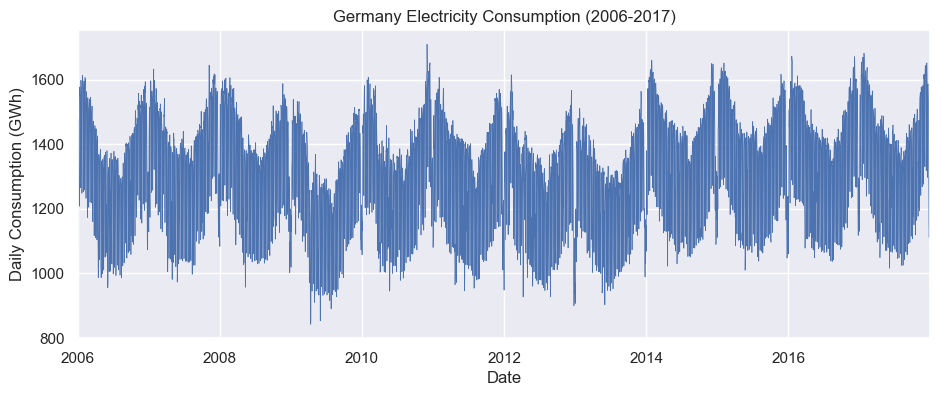

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(rc={'figure.figsize':(11, 4)})

opsd_daily['Consumption'].plot(linewidth=0.5)
plt.ylabel('Daily Consumption (GWh)')
plt.title('Germany Electricity Consumption (2006-2017)')
plt.show()

# Let's zoom in on the weekends

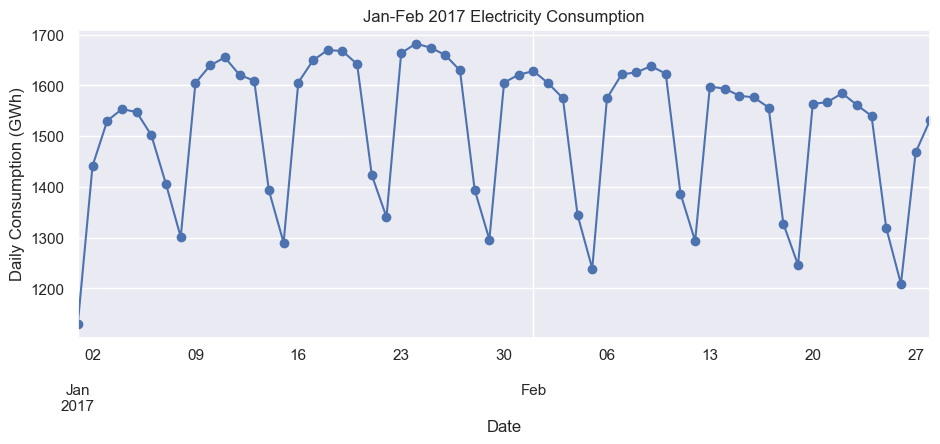

In [8]:

ax = opsd_daily.loc['2017-01':'2017-02', 'Consumption'].plot(marker='o', linestyle='-')
ax.set_ylabel('Daily Consumption (GWh)')
ax.set_title('Jan-Feb 2017 Electricity Consumption')
plt.show()

# Frequencies and Resampling

In [9]:
opsd_weekly_mean = opsd_daily['Consumption'].resample('W').mean()
print(opsd_weekly_mean.head(3))

Date
2006-01-01    1069.184000
2006-01-08    1381.300143
2006-01-15    1486.730286
Freq: W-SUN, Name: Consumption, dtype: float64


# Compare Daily vs. Weekly Data

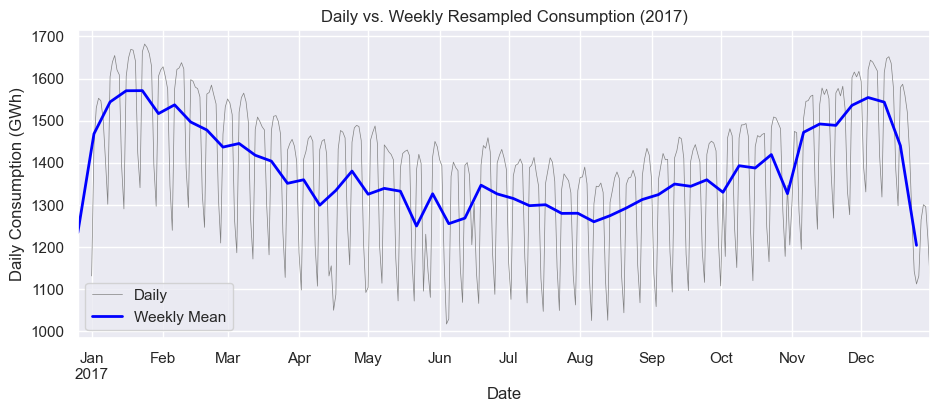

In [10]:
fig, ax = plt.subplots()
opsd_daily.loc['2017', 'Consumption'].plot(ax=ax, color='0.5', linewidth=0.5, label='Daily')
opsd_weekly_mean.loc['2017'].plot(ax=ax, color='blue', linewidth=2, label='Weekly Mean')

ax.set_ylabel('Daily Consumption (GWh)')
ax.set_title('Daily vs. Weekly Resampled Consumption (2017)')
ax.legend()
plt.show()

# Rolling Windows in Pandas

In [11]:
opsd_7d = opsd_daily['Consumption'].rolling(7, center=True).mean()
print(opsd_7d.head(10))

Date
2006-01-01            NaN
2006-01-02            NaN
2006-01-03            NaN
2006-01-04    1361.471429
2006-01-05    1381.300143
2006-01-06    1402.557571
2006-01-07    1421.754429
2006-01-08    1438.891429
2006-01-09    1449.769857
2006-01-10    1469.994857
Name: Consumption, dtype: float64


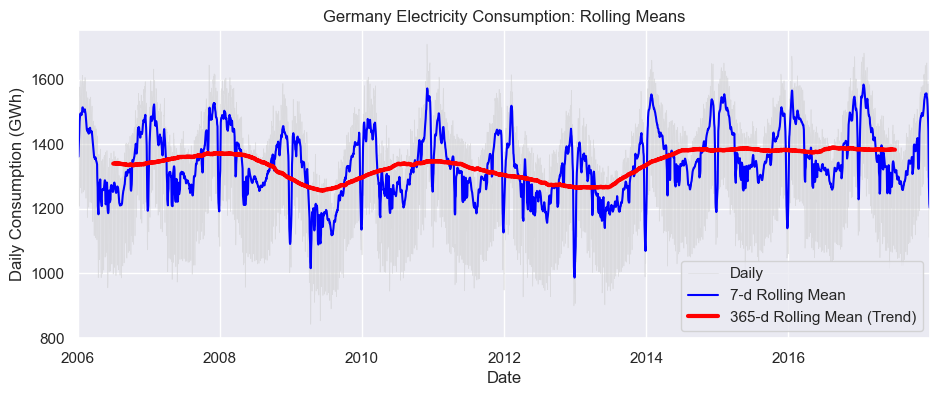

In [12]:
fig, ax = plt.subplots()
opsd_daily['Consumption'].plot(ax=ax, color='0.8', linewidth=0.5, alpha=0.5, label='Daily')
opsd_7d.plot(ax=ax, color='blue', linewidth=1.5, label='7-d Rolling Mean')
opsd_365d = opsd_daily['Consumption'].rolling(365, center=True).mean()
opsd_365d.plot(ax=ax, color='red', linewidth=3, label='365-d Rolling Mean (Trend)')

ax.set_ylabel('Daily Consumption (GWh)')
ax.set_title('Germany Electricity Consumption: Rolling Means')
ax.legend()
plt.show()

# Analyzing the Renewable Energy Trend

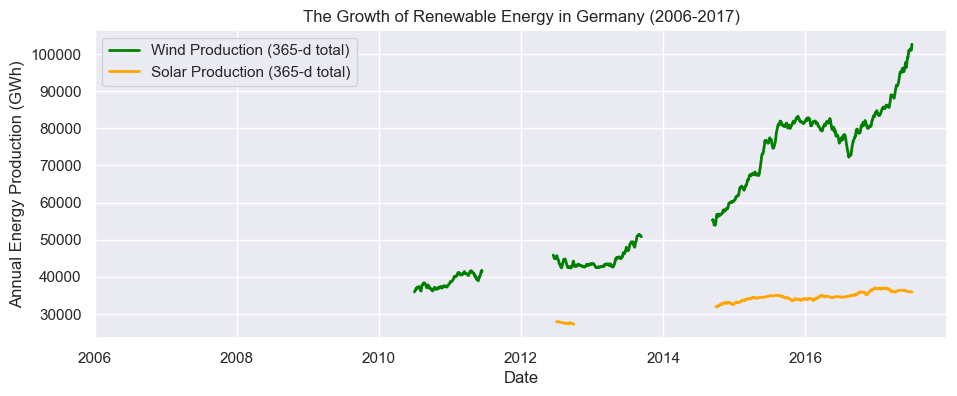

In [13]:
renewable_trend = opsd_daily[['Wind', 'Solar']].rolling(365, center=True).sum()

fig, ax = plt.subplots()

renewable_trend['Wind'].plot(ax=ax, color='green', linewidth=2, label='Wind Production (365-d total)')
renewable_trend['Solar'].plot(ax=ax, color='orange', linewidth=2, label='Solar Production (365-d total)')

ax.set_ylabel('Annual Energy Production (GWh)')
ax.set_title('The Growth of Renewable Energy in Germany (2006-2017)')
ax.legend()
plt.show()